## Conhecendo os dados

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/Mirlaa/regressao-arvores/main/dados_curso/entregas.csv'

url_teste = 'https://raw.githubusercontent.com/Mirlaa/regressao-arvores/main/dados_curso/teste_entregas.csv'

In [3]:
dados = pd.read_csv(url)

In [4]:
dados.head()

,id_cliente,nome_artista,reputacao_artista,altura,largura,peso,material,preco_escultura,preco_base_envio,internacional,envio_expresso,instalacao_incluida,transporte,fragil,pedido_extra_cliente,localizacao_remota,data_agendada,data_entrega,custo
0,e9dff114-bc2b-47e9-9f5c-669e32ad9bbe,Billy Jenkins,0.26,5.1816,1.8288,1872.427776,Latão,73027.5,85.4175,Sim,Sim,Não,Aéreo,Não,Sim,Não,07/06/19,03/06/19,1487.2725
1,ba3b707f-b123-4eec-93f4-1fbebfe72b68,Jean Bryant,0.28,0.9144,0.9144,27.669112,Latão,35857.5,78.7500,Não,Não,Não,Rodoviário,Não,Sim,Não,06/03/21,05/03/21,839.7900
2,c4212086-3e22-489e-bc2e-0d5092ef0526,Laura Miller,0.07,2.4384,1.5240,107.501304,Argila,26040.0,111.1950,Não,Não,Não,Rodoviário,Sim,Sim,Sim,09/03/19,08/03/19,810.0225
3,fec1bee9-44cf-498f-a849-5e5e2cab062b,Robert Chaires,0.12,2.7432,2.4384,1407.042384,Alumínio,30502.5,85.6275,Não,Não,Não,Não especificado,Não,Não,Sim,24/05/19,20/05/19,846.0900
4,f9f2ed8c-7f56-4e69-a80e-cb01d0a711da,Rosalyn Krol,0.15,5.1816,1.8288,146.963808,Alumínio,16695.0,62.6850,Sim,Sim,Sim,Aéreo,Não,Sim,Não,18/12/20,14/12/20,835.9575


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            4462 non-null   object 
 1   nome_artista          4462 non-null   object 
 2   reputacao_artista     4462 non-null   float64
 3   altura                4462 non-null   float64
 4   largura               4462 non-null   float64
 5   peso                  4462 non-null   float64
 6   material              4462 non-null   object 
 7   preco_escultura       4462 non-null   float64
 8   preco_base_envio      4462 non-null   float64
 9   internacional         4462 non-null   object 
 10  envio_expresso        4462 non-null   object 
 11  instalacao_incluida   4462 non-null   object 
 12  transporte            4462 non-null   object 
 13  fragil                4462 non-null   object 
 14  pedido_extra_cliente  4462 non-null   object 
 15  localizacao_remota   

### Ajustando valores de tipo data

In [6]:
df = dados.copy()

In [7]:
df['data_agendada'] = pd.to_datetime(df['data_agendada'], format='%d/%m/%y')
df['data_entrega'] = pd.to_datetime(df['data_entrega'], format='%d/%m/%y')

In [8]:
df['diferenca_dias_entrega'] = (df['data_entrega'] - df['data_agendada']).dt.days

In [9]:
df['data_agendada_dias'] = df['data_agendada'].dt.day
df['data_agendada_mes'] = df['data_agendada'].dt.month
df['data_agendada_ano'] = df['data_agendada'].dt.year

In [10]:
df['data_entrega_dias'] = df['data_entrega'].dt.day
df['data_entrega_mes'] = df['data_entrega'].dt.month
df['data_entrega_ano'] = df['data_entrega'].dt.year

In [11]:
df.drop(columns = ['data_agendada', 'data_entrega'], inplace=True)

### Tratando valores categóricos

In [12]:
colunas_categoricas = ['id_cliente', 'nome_artista', 'material', 'internacional', 'envio_expresso', 'instalacao_incluida', 'transporte', 'fragil', 'pedido_extra_cliente','localizacao_remota']

for column in colunas_categoricas:
    unique_values = df[column].unique()
    print(f"Valores únicos na coluna '{column}' \n {len(unique_values)} valores:")
    print(unique_values)
    print('=='*45)

Valores únicos na coluna 'id_cliente' 
 4462 valores:
['e9dff114-bc2b-47e9-9f5c-669e32ad9bbe'
 'ba3b707f-b123-4eec-93f4-1fbebfe72b68'
 'c4212086-3e22-489e-bc2e-0d5092ef0526' ...
 'e1004685-9047-4f34-9103-57d900716936'
 'a380ff88-2c96-4d70-919a-af0bc8caeed7'
 '26fea648-9cc1-4a2b-9458-0b2d35957803']
Valores únicos na coluna 'nome_artista' 
 4441 valores:
['Billy Jenkins' 'Jean Bryant' 'Laura Miller' ... 'William Curry'
 'Karen Bayles' 'Denise Worth']
Valores únicos na coluna 'material' 
 8 valores:
['Latão' 'Argila' 'Alumínio' 'Madeira' 'Bronze' 'Pedra' 'Não especificado'
 'Mármore']
Valores únicos na coluna 'internacional' 
 2 valores:
['Sim' 'Não']
Valores únicos na coluna 'envio_expresso' 
 2 valores:
['Sim' 'Não']
Valores únicos na coluna 'instalacao_incluida' 
 2 valores:
['Não' 'Sim']
Valores únicos na coluna 'transporte' 
 4 valores:
['Aéreo' 'Rodoviário' 'Não especificado' 'Aquaviário']
Valores únicos na coluna 'fragil' 
 2 valores:
['Não' 'Sim']
Valores únicos na coluna 'pedido_

In [13]:
categoricas = ['internacional', 'envio_expresso', 'instalacao_incluida', 'fragil', 'pedido_extra_cliente', 'localizacao_remota', 'material', 'transporte']

df = pd.get_dummies(df, columns = categoricas,
                    prefix= categoricas, drop_first=True)

In [14]:
df.drop(columns = ['id_cliente', 'nome_artista'], inplace=True)

In [15]:
df.head()

,reputacao_artista,altura,largura,peso,preco_escultura,preco_base_envio,custo,diferenca_dias_entrega,data_agendada_dias,data_agendada_mes,...,material_Argila,material_Bronze,material_Latão,material_Madeira,material_Mármore,material_Não especificado,material_Pedra,transporte_Aéreo,transporte_Não especificado,transporte_Rodoviário
0,0.26,5.1816,1.8288,1872.427776,73027.5,85.4175,1487.2725,-4,7,6,...,False,False,True,False,False,False,False,True,False,False
1,0.28,0.9144,0.9144,27.669112,35857.5,78.7500,839.7900,-1,6,3,...,False,False,True,False,False,False,False,False,False,True
2,0.07,2.4384,1.5240,107.501304,26040.0,111.1950,810.0225,-1,9,3,...,True,False,False,False,False,False,False,False,False,True
3,0.12,2.7432,2.4384,1407.042384,30502.5,85.6275,846.0900,-4,24,5,...,False,False,False,False,False,False,False,False,True,False
4,0.15,5.1816,1.8288,146.963808,16695.0,62.6850,835.9575,-4,18,12,...,False,False,False,False,False,False,False,True,False,False


### Visualizando dados

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

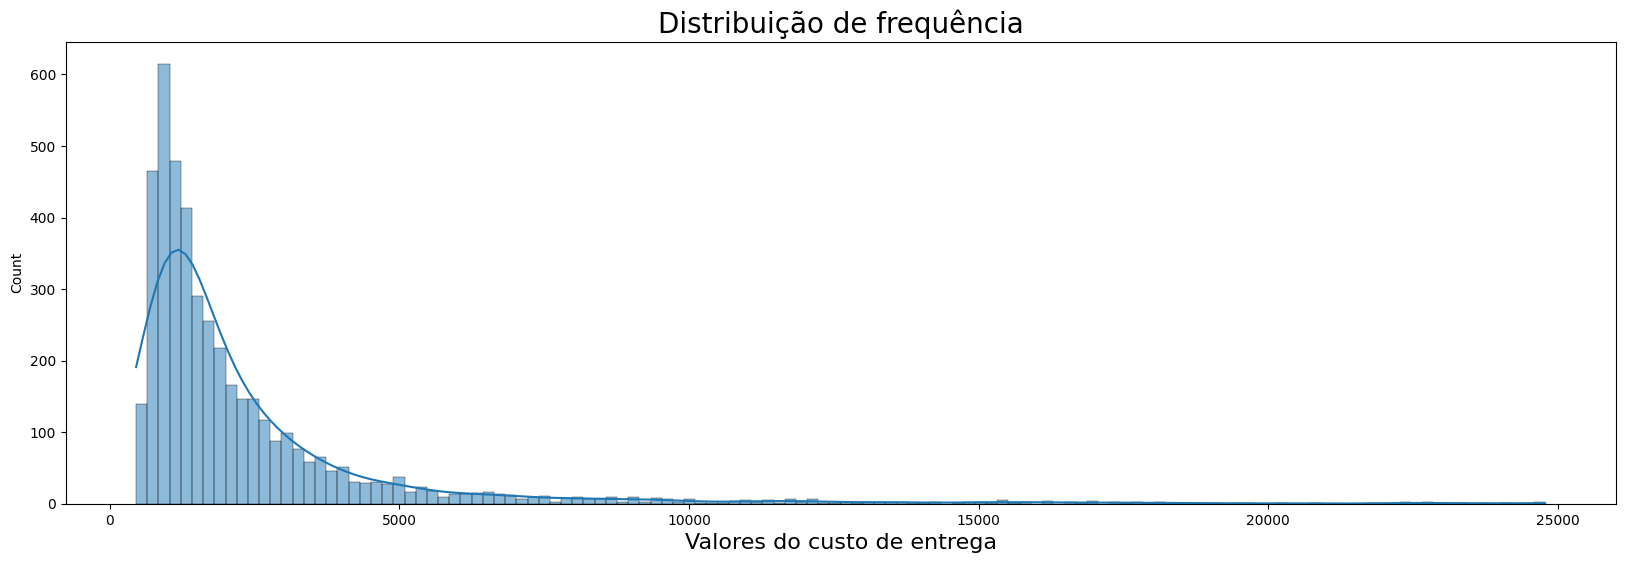

In [17]:
ax = sns.histplot(df['custo'], kde=True)

ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Valores do custo de entrega', fontsize=16)
plt.show()

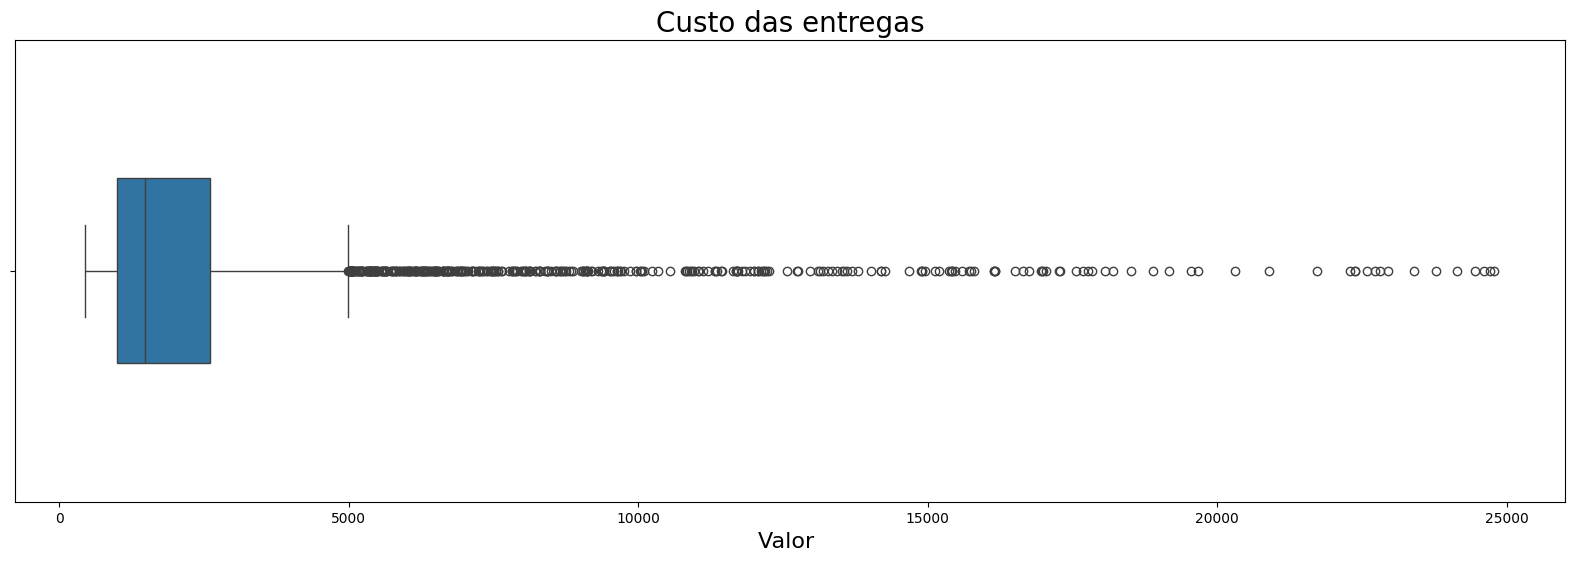

In [18]:
ax = sns.boxplot(df, x ="custo", width=0.4)

ax.figure.set_size_inches(20, 6)
ax.set_title('Custo das entregas', fontsize=20)
ax.set_xlabel('Valor ', fontsize=16)
plt.show()

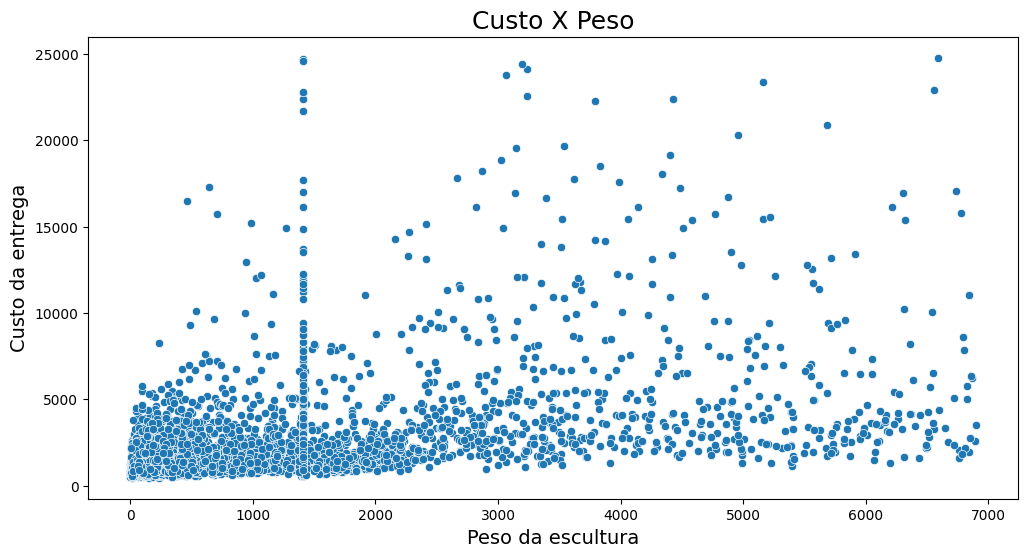

In [19]:
ax = sns.scatterplot(df, x='peso', y='custo')

ax.figure.set_size_inches(12, 6)
ax.set_title('Custo X Peso', fontsize=18)
ax.set_xlabel('Peso da escultura', fontsize=14)
ax.set_ylabel('Custo da entrega', fontsize=14)
plt.show()

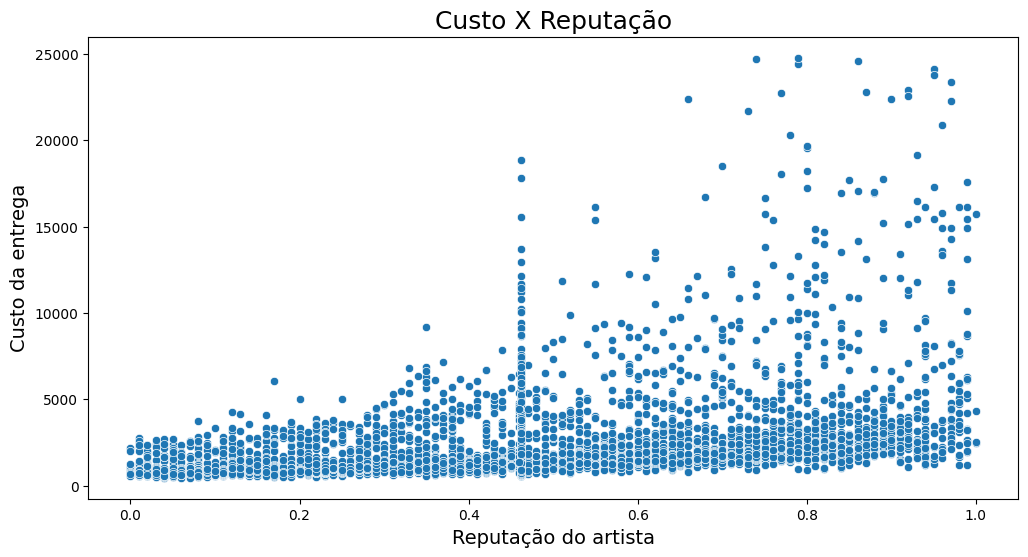

In [20]:
ax = sns.scatterplot(df, x='reputacao_artista', y='custo')

ax.figure.set_size_inches(12, 6)
ax.set_title('Custo X Reputação', fontsize=18)
ax.set_xlabel('Reputação do artista', fontsize=14)
ax.set_ylabel('Custo da entrega', fontsize=14)
plt.show()

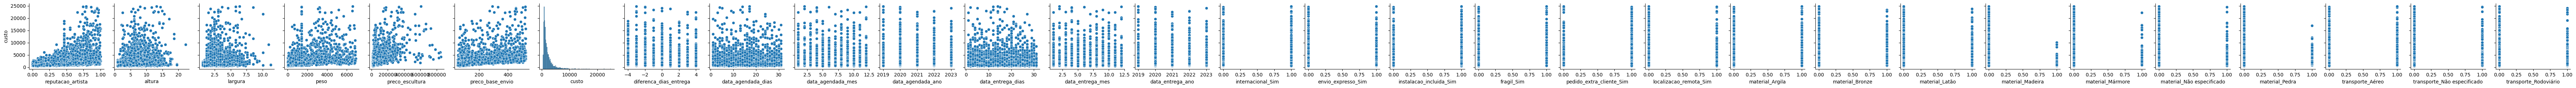

In [21]:
sns.pairplot(df, y_vars='custo')
ax.figure.suptitle('Dispersão entre as Variáveis', fontsize=20, y=1.05)
plt.show()

## Construindo Árvore de Regressão

### Preparando dados para o modelo

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df.drop(columns = 'custo')
y = df['custo']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=45)

In [24]:
len(X_teste), len(X_treino)

(893, 3569)

### Iniciando a construção do modelo

In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
dtr = DecisionTreeRegressor(random_state=45)
dtr.fit(X_treino, y_treino)

DecisionTreeRegressor(random_state=45)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, dtr.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, dtr.predict(X_treino)))
print('RMSE:', np.sqrt(mean_squared_error(y_treino, dtr.predict(X_treino))))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, dtr.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, dtr.predict(X_teste)))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, dtr.predict(X_teste))))

Métricas conjunto de treino:
R²: 1.0
MAE: 0.0
RMSE: 0.0


Métricas conjunto de teste:
R²: 0.660591437323694
MAE: 694.1638773796193
RMSE: 1544.651772523526


In [28]:
print(f"Número de nós: {dtr.tree_.node_count}")
print(f"Número de folhas: {dtr.tree_.n_leaves}")
print(f"Profundidade máxima: {dtr.tree_.max_depth}")

Número de nós: 7135
Número de folhas: 3568
Profundidade máxima: 30


In [29]:
dtr.feature_names_in_

array(['reputacao_artista', 'altura', 'largura', 'peso',
       'preco_escultura', 'preco_base_envio', 'diferenca_dias_entrega',
       'data_agendada_dias', 'data_agendada_mes', 'data_agendada_ano',
       'data_entrega_dias', 'data_entrega_mes', 'data_entrega_ano',
       'internacional_Sim', 'envio_expresso_Sim',
       'instalacao_incluida_Sim', 'fragil_Sim',
       'pedido_extra_cliente_Sim', 'localizacao_remota_Sim',
       'material_Argila', 'material_Bronze', 'material_Latão',
       'material_Madeira', 'material_Mármore',
       'material_Não especificado', 'material_Pedra', 'transporte_Aéreo',
       'transporte_Não especificado', 'transporte_Rodoviário'],
      dtype=object)

In [30]:
dtr.feature_importances_

array([2.95578488e-01, 4.29089881e-02, 3.78042354e-02, 2.21994392e-02,
       3.84947343e-01, 1.49395147e-01, 1.22586707e-02, 1.11972117e-02,
       2.86561159e-03, 1.99295839e-03, 1.14020224e-02, 3.54964474e-03,
       1.57834550e-03, 6.77238263e-04, 5.94807112e-03, 2.79459433e-03,
       4.12356992e-03, 9.82178117e-04, 9.73419750e-04, 6.98369997e-04,
       2.13022242e-04, 7.89364354e-04, 1.61255529e-04, 1.65835374e-04,
       7.69720325e-04, 1.19398420e-05, 2.27767179e-03, 1.43086476e-03,
       3.04778449e-04])

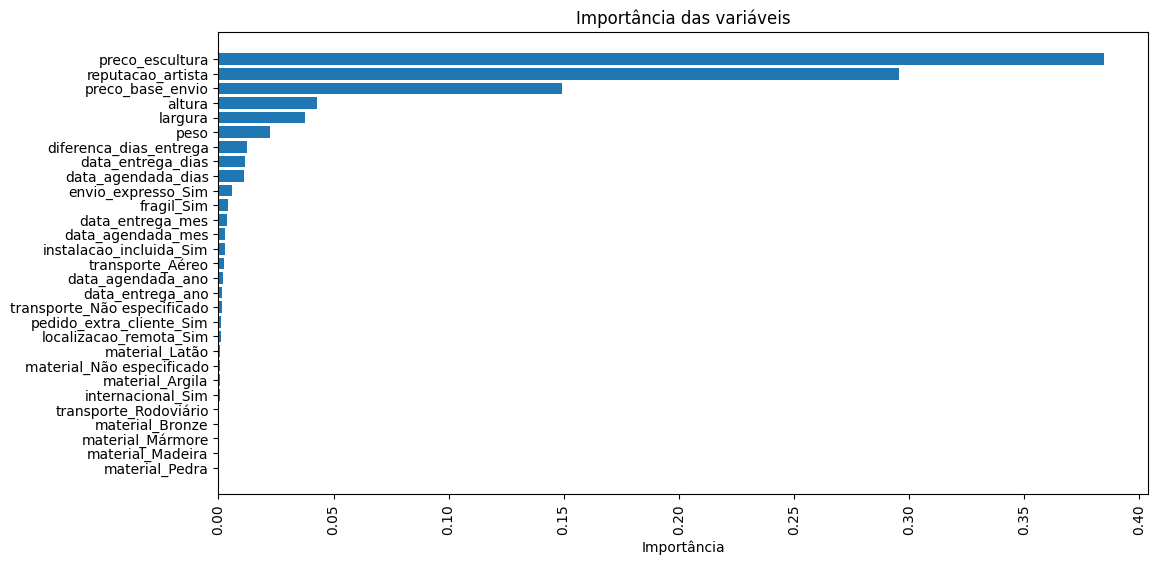

In [31]:
importancia = pd.DataFrame(dtr.feature_importances_, index=dtr.feature_names_in_, columns=['Importância']).sort_values(by='Importância')

plt.figure(figsize=(12, 6))
bars = plt.barh(importancia.index, importancia['Importância'])
plt.xlabel('Importância')
plt.title('Importância das variáveis')
plt.xticks(rotation=90)
plt.show()

In [32]:
dtr.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 45,
 'splitter': 'best'}

In [33]:
# from sklearn.tree import plot_tree

# plt.figure(figsize=(25, 15))
# plot_tree(dtr, feature_names=X.columns, filled=True, rounded=True)
# plt.title('Árvore de Decisão de Regressão')
# plt.show()

## Evitando Overfitting com a otimização

In [34]:
param_grid = {
    'max_depth': [6, 8, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 15],
    'max_leaf_nodes': [None, 100, 500]
}

### Executando a busca Grid

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
grid_search = GridSearchCV(dtr, param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_search.fit(X_treino, y_treino)

dtr_otimizado = grid_search.best_estimator_

print(f'Os melhores parâmetros são: {grid_search.best_params_}')

Os melhores parâmetros são: {'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [37]:
print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, dtr_otimizado.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, dtr_otimizado.predict(X_treino)))
print('RMSE:', np.sqrt(mean_squared_error(y_treino, dtr_otimizado.predict(X_treino))))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, dtr_otimizado.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, dtr_otimizado.predict(X_teste)))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, dtr_otimizado.predict(X_teste))))

Métricas conjunto de treino:
R²: 0.8709496124958277
MAE: 473.70848177515785
RMSE: 980.4175958553703


Métricas conjunto de teste:
R²: 0.7539366877133971
MAE: 586.9786990247475
RMSE: 1315.2024908853869


### Executando a validação da nova árvore

In [38]:
from sklearn.model_selection import cross_validate, KFold

cv_estrategia = KFold(n_splits=3, shuffle=True, random_state=45)

resultados = cross_validate(dtr_otimizado, X, y, cv=cv_estrategia, scoring='neg_mean_squared_error', return_train_score=True)

In [39]:
treino_rmse = np.sqrt(-resultados['train_score'])
teste_rmse = np.sqrt(-resultados['test_score'])

print("Treino RMSE em cada fold:", treino_rmse)
print("Teste RMSE em cada fold:", teste_rmse)
print("\nMédia do RMSE no treino:", treino_rmse.mean())
print("Média do RMSE no teste:", teste_rmse.mean())

Treino RMSE em cada fold: [1061.33787095  985.34242721 1023.82861998]
Teste RMSE em cada fold: [1359.22040707 1469.19123426 1424.79371964]

Média do RMSE no treino: 1023.5029727125925
Média do RMSE no teste: 1417.7351203213384


In [40]:
print(f"Número de nós: {dtr_otimizado.tree_.node_count}")
print(f"Número de folhas: {dtr_otimizado.tree_.n_leaves}")
print(f"Profundidade máxima: {dtr_otimizado.tree_.max_depth}")

Número de nós: 381
Número de folhas: 191
Profundidade máxima: 10


In [41]:
dtr_otimizado.feature_names_in_

array(['reputacao_artista', 'altura', 'largura', 'peso',
       'preco_escultura', 'preco_base_envio', 'diferenca_dias_entrega',
       'data_agendada_dias', 'data_agendada_mes', 'data_agendada_ano',
       'data_entrega_dias', 'data_entrega_mes', 'data_entrega_ano',
       'internacional_Sim', 'envio_expresso_Sim',
       'instalacao_incluida_Sim', 'fragil_Sim',
       'pedido_extra_cliente_Sim', 'localizacao_remota_Sim',
       'material_Argila', 'material_Bronze', 'material_Latão',
       'material_Madeira', 'material_Mármore',
       'material_Não especificado', 'material_Pedra', 'transporte_Aéreo',
       'transporte_Não especificado', 'transporte_Rodoviário'],
      dtype=object)

In [42]:
dtr_otimizado.feature_importances_

array([3.17577990e-01, 3.65159553e-02, 3.00136876e-02, 2.85288219e-03,
       4.31070936e-01, 1.61369426e-01, 3.33834967e-03, 3.32861877e-03,
       4.56730901e-04, 0.00000000e+00, 1.13117724e-04, 1.37499301e-03,
       7.42694237e-04, 3.50648025e-04, 5.20409049e-03, 4.41472992e-04,
       4.51854304e-03, 1.84968235e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.68358741e-06, 7.43478119e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.28778057e-04,
       0.00000000e+00])

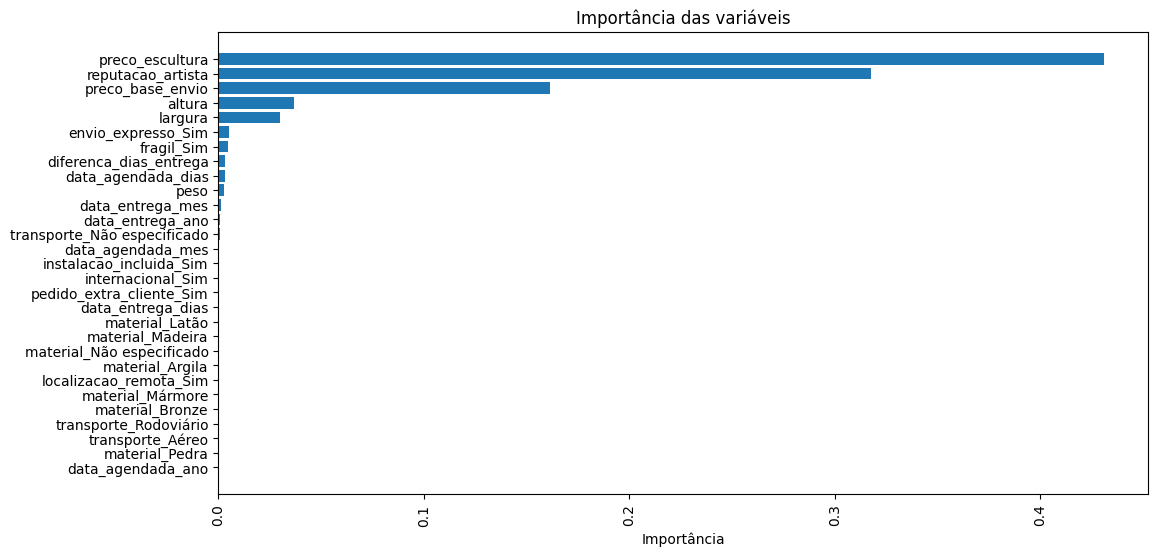

In [43]:
importancia = pd.DataFrame(dtr_otimizado.feature_importances_, index=dtr_otimizado.feature_names_in_, columns=['Importância']).sort_values(by='Importância')

plt.figure(figsize=(12, 6))
bars = plt.barh(importancia.index, importancia['Importância'])
plt.xlabel('Importância')
plt.title('Importância das variáveis')
plt.xticks(rotation=90)
plt.show()

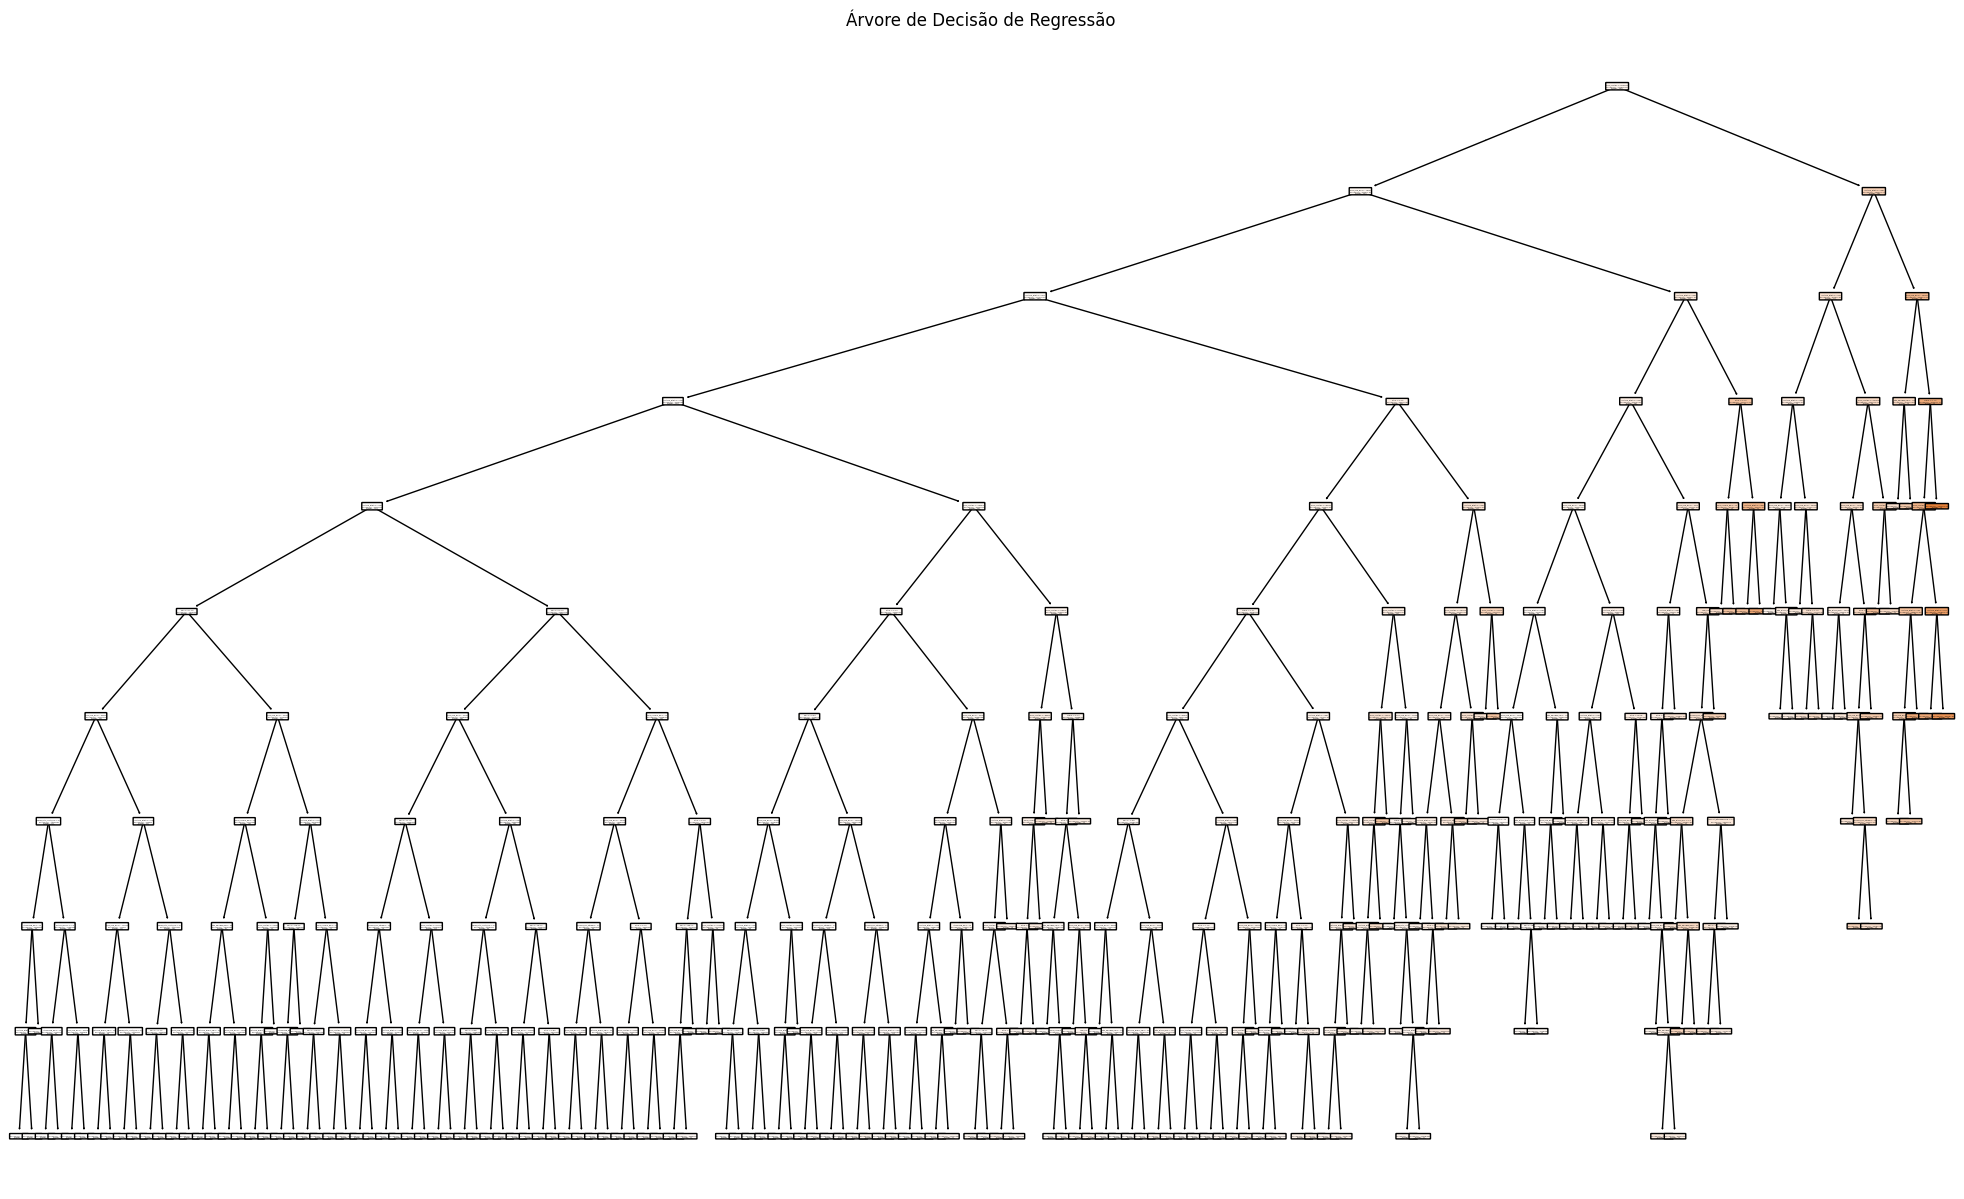

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(dtr_otimizado, feature_names=X.columns, filled=True, rounded=True)
plt.title('Árvore de Decisão de Regressão')
plt.show()

## Implementando uma Floresta Aleatória

### Conhecendo a Floresta Aleatória

In [46]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, random_state=45, oob_score=True)
rfr.fit(X_treino, y_treino)

RandomForestRegressor(oob_score=True, random_state=45)

### Avaliando a Floresta Aleatória

In [48]:
print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, rfr.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, rfr.predict(X_treino)))
print('RMSE:', np.sqrt(mean_squared_error(y_treino, rfr.predict(X_treino))))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, rfr.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, rfr.predict(X_teste)))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, rfr.predict(X_teste))))

print('\n\nPrevisão dos valores Out-of-Bag R²:', rfr.oob_score_)

Métricas conjunto de treino:
R²: 0.9772974668010325
MAE: 183.67128603950695
RMSE: 411.21467064130854


Métricas conjunto de teste:
R²: 0.8253561789085245
MAE: 459.512885106383
RMSE: 1108.015414498702


Previsão dos valores Out-of-Bag R²: 0.8283734967539083



### Validando a Floresta Aleatória

In [49]:
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=45)

results = cross_validate(rfr, X, y, scoring='neg_mean_squared_error', cv=cv_strategy, return_train_score=True)


train_rmse_scores = np.sqrt(-results['train_score'])
test_rmse_scores = np.sqrt(-results['test_score'])


print("Média do RMSE no treino:", train_rmse_scores.mean())
print("Média do RMSE no teste:", test_rmse_scores.mean())

Média do RMSE no treino: 426.80944484310663
Média do RMSE no teste: 1148.5596272436603


In [52]:
df['custo'].mean()

np.float64(2382.2115379874494)

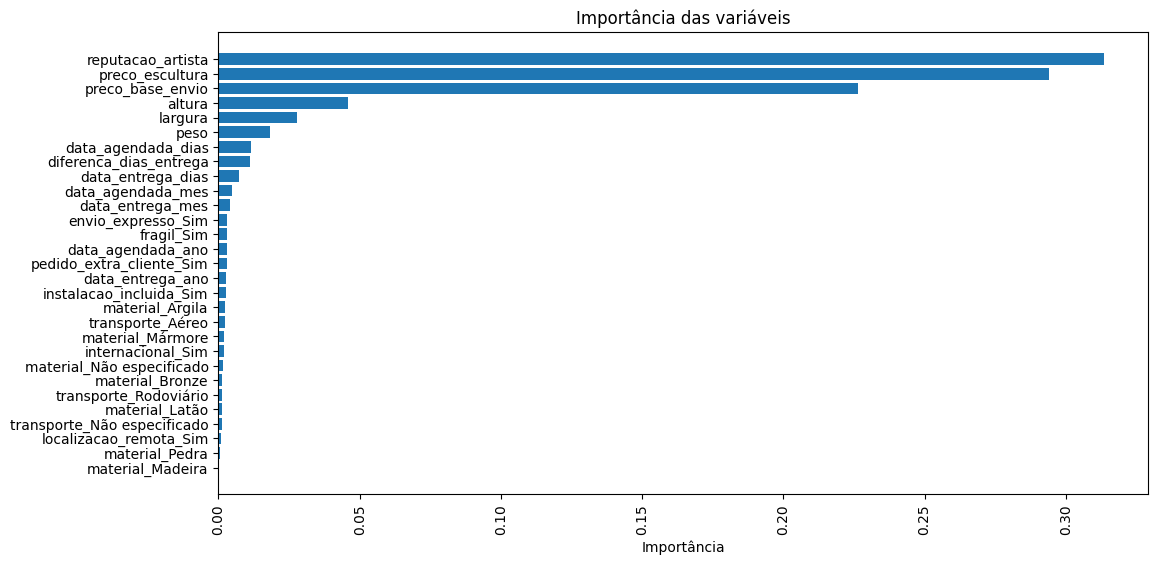

In [53]:
importancia = pd.DataFrame(rfr.feature_importances_, index=rfr.feature_names_in_, columns=['Importância']).sort_values(by='Importância')

plt.figure(figsize=(12, 6))
bars = plt.barh(importancia.index, importancia['Importância'])
plt.xlabel('Importância')
plt.title('Importância das variáveis')
plt.xticks(rotation=90)
plt.show()

## Buscando a otimização da Floresta Aleatória

### Aplicando o Grid Search

In [62]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.7, 1.0],
    'max_leaf_nodes': [550, 800, 1000]
}

In [66]:
from sklearn.model_selection import RandomizedSearchCV

# Definimos o mesmo dicionário de parâmetros
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.7, 1.0],
    'max_leaf_nodes': [500, 700, 1000]
}

# O segredo está no 'n_iter'
rfr_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=60,      # Ele vai testar apenas 30 combinações aleatórias
    cv=5,           # Validação cruzada
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rfr_random.fit(X_treino, y_treino)

print("Melhores parâmetros encontrados:", rfr_random.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros encontrados: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': 500, 'max_features': 0.7, 'max_depth': 20}


In [68]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.6 MB/s eta 0:00:00


In [69]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


# Definimos o espaço de busca com tipos específicos (Integer, Real, etc)
search_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(5, 35),
    'min_samples_leaf': Integer(1, 5),
    'min_samples_split': Integer(2, 10),
    'max_features': Real(0.5, 1.0, prior='uniform'),
    'max_leaf_nodes': Integer(100, 1000)
}

# Configuramos o BayesSearchCV
rfr_bayes = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=45),
    search_spaces=search_space,
    n_iter=32,        # Quantas vezes ele vai tentar (32 costuma ser um bom equilíbrio)
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error', # Otimizando para reduzir o erro
    random_state=45,
    verbose=0
)

# Executando a busca
rfr_bayes.fit(X_treino, y_treino)

print("Melhores parâmetros encontrados:", rfr_bayes.best_params_)

Melhores parâmetros encontrados: OrderedDict({'max_depth': 35, 'max_features': 0.7696629595924078, 'max_leaf_nodes': 1000, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 366})


### Avaliando o modelo gerado

In [70]:
print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, rfr_random.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, rfr_random.predict(X_treino)))
print('RMSE:', np.sqrt(mean_squared_error(y_treino, rfr_random.predict(X_treino))))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, rfr_random.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, rfr_random.predict(X_teste)))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, rfr_random.predict(X_teste))))

Métricas conjunto de treino:
R²: 0.959981136705469
MAE: 237.3592762243339
RMSE: 545.963758587266


Métricas conjunto de teste:
R²: 0.815006249779376
MAE: 462.78198726677607
RMSE: 1140.375079364574


In [71]:
print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, rfr_bayes.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, rfr_bayes.predict(X_treino)))
print('RMSE:', np.sqrt(mean_squared_error(y_treino, rfr_bayes.predict(X_treino))))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, rfr_bayes.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, rfr_bayes.predict(X_teste)))
print('RMSE:', np.sqrt(mean_squared_error(y_teste, rfr_bayes.predict(X_teste))))

Métricas conjunto de treino:
R²: 0.9683470480347223
MAE: 209.5401457537772
RMSE: 485.5551333938789


Métricas conjunto de teste:
R²: 0.8137846262421075
MAE: 469.03203615513246
RMSE: 1144.1341704627432


In [72]:
modelo = rfr_bayes.best_estimator_

In [73]:
cv_estrategia = KFold(n_splits=3, shuffle=True, random_state=45)

resultados = cross_validate(modelo, X, y, scoring='neg_mean_squared_error', cv=cv_estrategia, return_train_score=True)

treino_rmse = np.sqrt(-resultados['train_score'])
teste_rmse = np.sqrt(-resultados['test_score'])

print("Média do RMSE no treino:", treino_rmse.mean())
print("Média do RMSE no teste:", teste_rmse.mean())

Média do RMSE no treino: 502.0089280941284
Média do RMSE no teste: 1133.097990908771


### Prevendo novos dados

In [74]:
url = 'https://raw.githubusercontent.com/Mirlaa/regressao-arvores/main/dados_curso/entregas.csv'

url_teste = 'https://raw.githubusercontent.com/Mirlaa/regressao-arvores/main/dados_curso/teste_entregas.csv'

In [75]:
novos_dados = pd.read_csv(url_teste)

In [76]:
custos = modelo.predict(novos_dados)

novos_dados['custo'] = custos
novos_dados

,reputacao_artista,altura,largura,peso,preco_escultura,preco_base_envio,diferenca_dias_entrega,data_agendada_dias,data_agendada_mes,data_agendada_ano,...,material_Bronze,material_Latão,material_Madeira,material_Mármore,material_Não especificado,material_Pedra,transporte_Aéreo,transporte_Não especificado,transporte_Rodoviário,custo
0,0.67,2.1336,1.2192,48.987936,36.3300,73.2900,0,2,5,2020,...,False,False,False,False,False,False,False,False,True,1182.145894
1,0.61,1.8288,1.5240,43.998424,22.2075,71.5050,2,4,1,2022,...,False,False,False,False,False,False,True,False,False,1142.075970
2,0.14,4.5720,2.4384,343.369144,32.9700,124.8975,3,14,9,2021,...,False,False,False,False,False,False,False,False,True,990.576552
3,0.63,3.0480,1.2192,758.859416,23.0475,93.6075,-1,3,12,2021,...,False,False,False,True,False,False,False,False,True,1637.089653
4,0.34,9.7536,1.8288,505.755080,34.9125,119.7000,4,3,2,2022,...,False,False,False,False,False,False,True,False,False,1434.844784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,0.00,2.1336,1.5240,736.179816,22.6275,113.1375,-3,14,11,2021,...,False,False,False,True,False,False,True,False,False,1002.835267
1430,0.10,3.6576,1.8288,390.996304,27.7725,80.6400,0,9,12,2019,...,True,False,False,False,False,False,False,False,True,759.446111
1431,0.20,1.2192,1.2192,9.071840,31.0800,105.5250,4,6,3,2022,...,False,False,False,False,False,False,False,False,True,797.257663
1432,0.22,9.7536,2.4384,488.972176,27.7725,112.8225,-3,21,2,2023,...,False,False,False,False,False,False,False,False,False,1087.076460
